In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Loading movie's ratings data
ratings = pd.read_csv("../Raw_Data/ratings.dat", header=None, delimiter="::")
#https://grouplens.org/datasets/movielens/1m/

### 1. Explory Data Analysis: Basics

In [3]:
ratings.shape

(1000209, 4)

In [4]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000209 entries, 0 to 1000208
Data columns (total 4 columns):
 #   Column  Non-Null Count    Dtype
---  ------  --------------    -----
 0   0       1000209 non-null  int64
 1   1       1000209 non-null  int64
 2   2       1000209 non-null  int64
 3   3       1000209 non-null  int64
dtypes: int64(4)
memory usage: 30.5 MB


In [5]:
small_rat = ratings.iloc[0:10000, 0:4]

In [6]:
small_rat.shape

(10000, 4)

In [7]:
small_rat.head()

,0,1,2,3
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [8]:
ratings.rename(columns={0:"UserID", 1:"MovieID", 2:"Rating", 3:"Timestamp"}, inplace=True)

In [9]:
small_rat = ratings.iloc[0:100000, 0:3]

#### 1.1 small sample properties : Ratings distribution

<Axes: >

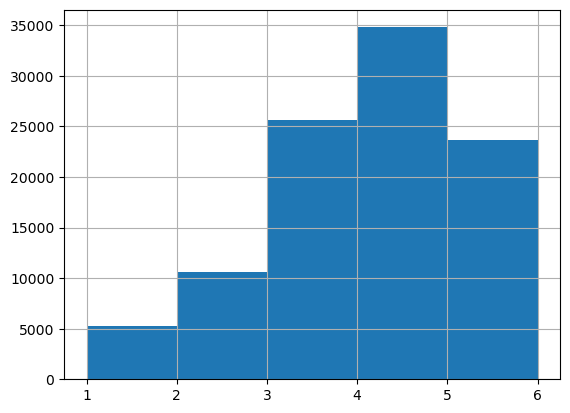

In [10]:
small_rat.Rating.hist(bins=[1,2,3,4,5,6])

In [11]:
small_rat.Rating.describe()

count    100000.000000
mean          3.610140
std           1.113338
min           1.000000
25%           3.000000
50%           4.000000
75%           4.000000
max           5.000000
Name: Rating, dtype: float64

#### 1.2 Number of movies and users

In [12]:
max_Movie_Id = small_rat.MovieID.max()
print("Max ID of movies in the small ratings sample: " + str(max_Movie_Id))

Max ID of movies in the small ratings sample: 3952


In [13]:
count_Movie_Id = small_rat.MovieID.nunique()
print("Number of Movie ID in the small ratings sample: " + str(count_Movie_Id))

Number of Movie ID in the small ratings sample: 3264


In [14]:
max_User_Id = small_rat.UserID.max()
print("Max ID of User in the small ratings sample: " + str(max_User_Id))

Max ID of User in the small ratings sample: 669


In [15]:
count_User_Id = small_rat.UserID.nunique()
print("Number of User ID in the small ratings sample: " + str(count_User_Id))

Number of User ID in the small ratings sample: 669


In [ ]:
# we withdraw the last user to get a fair estimation of the taste of every users
small_rat = small_rat[small_rat["UserID"] != max_User_Id]
small_rat.shape

(99987, 3)

#### 1.4 Number of ratings per movie

In [17]:
nb_ratings_per_movie = small_rat[["MovieID", "UserID"]].groupby(by = "MovieID").count()

In [18]:
nb_ratings_per_movie.describe()

,UserID
count,3264.000000
mean,30.633272
std,42.128170
min,1.000000
25%,5.000000
50%,15.000000
75%,40.000000
max,406.000000


array([[<Axes: title={'center': 'UserID'}>]], dtype=object)

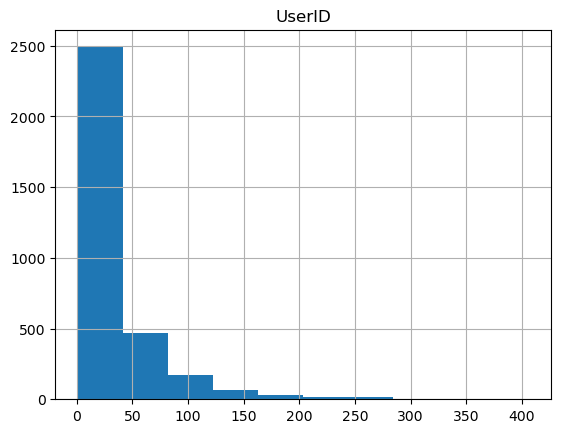

In [19]:
nb_ratings_per_movie.hist()

#### 1.5 Number of ratings per user

In [20]:
nb_ratings_per_user = small_rat[["MovieID", "UserID"]].groupby(by = "UserID").count()

In [21]:
nb_ratings_per_user.describe()

,MovieID
count,668.000000
mean,149.681138
std,172.474499
min,20.000000
25%,43.000000
50%,87.000000
75%,182.250000
max,1226.000000


array([[<Axes: title={'center': 'MovieID'}>]], dtype=object)

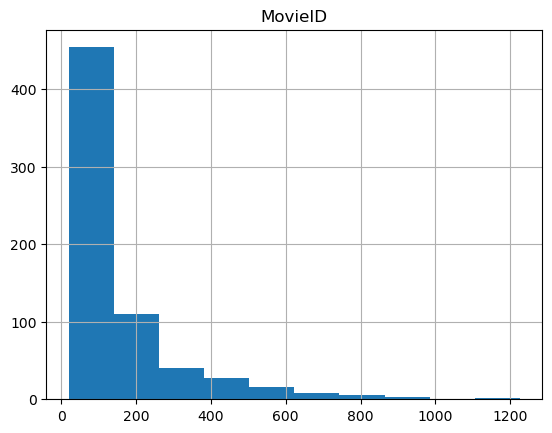

In [22]:
nb_ratings_per_user.hist()

### 2. Preparation of the dataset for collaborative filtering

#### 2.1 Getting movie titles

In [27]:
# Loading movie's ratings data
movies = pd.read_csv("../Raw_Data/movies.dat", header=None, delimiter="::", on_bad_lines='skip', encoding='ISO-8859-1')